### Import Libraries

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8')
%matplotlib inline

### Load Dataset

In [37]:
df = pd.read_csv("Virat_Kohli_ODI.csv")   
df.head()

,Runs,Mins,BF,4s,6s,SR,Pos,Dismissal,Inns,Opposition,Ground,Start Date
0,12,33,22,1,0,54.54,2,lbw,1,v Sri Lanka,Dambulla,18-Aug-08
1,37,82,67,6,0,55.22,2,caught,2,v Sri Lanka,Dambulla,20-Aug-08
2,25,40,38,4,0,65.78,1,run out,1,v Sri Lanka,Colombo (RPS),24-Aug-08
3,54,87,66,7,0,81.81,1,bowled,1,v Sri Lanka,Colombo (RPS),27-Aug-08
4,31,45,46,3,1,67.39,1,lbw,2,v Sri Lanka,Colombo (RPS),29-Aug-08


In [38]:
df.shape

(132, 12)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Runs                 132 non-null    int64         
 1   Mins                 126 non-null    float64       
 2   BF                   132 non-null    int64         
 3   4s                   132 non-null    int64         
 4   6s                   132 non-null    int64         
 5   SR                   131 non-null    float64       
 6   Pos                  132 non-null    int64         
 7   Dismissal            132 non-null    object        
 8   Inns                 132 non-null    int64         
 9   Opposition           132 non-null    object        
 10  Ground               132 non-null    object        
 11  Start Date           132 non-null    datetime64[ns]
 12  Not_Out              132 non-null    bool          
 13  Year                 132 non-null  

In [51]:
df.isnull().sum()

Runs                    0
Mins                    6
BF                      0
4s                      0
6s                      0
SR                      1
Pos                     0
Dismissal               0
Inns                    0
Opposition              0
Ground                  0
Start Date              0
Not_Out                 0
Year                    0
Boundary_Runs           0
Boundary_Percentage    10
dtype: int64

## Data Cleaning

In [57]:
#Handle Not Out
df['Not_Out'] = df['Runs'].astype(str).str.contains('\*')
df['Runs'] = df['Runs'].astype(str).str.replace('*', '', regex=False)
df['Runs'] = pd.to_numeric(df['Runs'], errors='coerce')

In [58]:
#Convert Date Column
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['Year'] = df['Start Date'].dt.year

In [54]:
#Convert Numeric Columns
numeric_cols = ['Runs','Mins','BF','4s','6s','SR','Pos','Inns']
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [55]:
#Create Boundary Features
df['Boundary_Runs'] = df['4s']*4 + df['6s']*6
df['Boundary_Percentage'] = (df['Boundary_Runs'] / df['Runs']) * 100

In [70]:
#Handle Missing Values
df['Mins'] = df['Mins'].fillna(df['Mins'].median())
df['SR'] = df['SR'].fillna(df['SR'].mean())
df['Boundary_Percentage'] = df['Boundary_Percentage'].fillna(0)

### Basic Career Statistics

In [60]:
total_matches = df.shape[0]
total_runs = df['Runs'].sum()
average = df['Runs'].mean()
strike_rate = df['SR'].mean()
highest_score = df['Runs'].max()
not_outs = df['Not_Out'].sum()

print("Total Matches:", total_matches)
print("Total Runs:", total_runs)
print("Batting Average:", round(average,2))
print("Overall Strike Rate:", round(strike_rate,2))
print("Highest Score:", highest_score)
print("Not Outs:", not_outs)

Total Matches: 132
Total Runs: 6184
Batting Average: 46.85
Overall Strike Rate: 77.58
Highest Score: 154
Not Outs: 0


### 50s and 100s

50s: 31
100s: 23


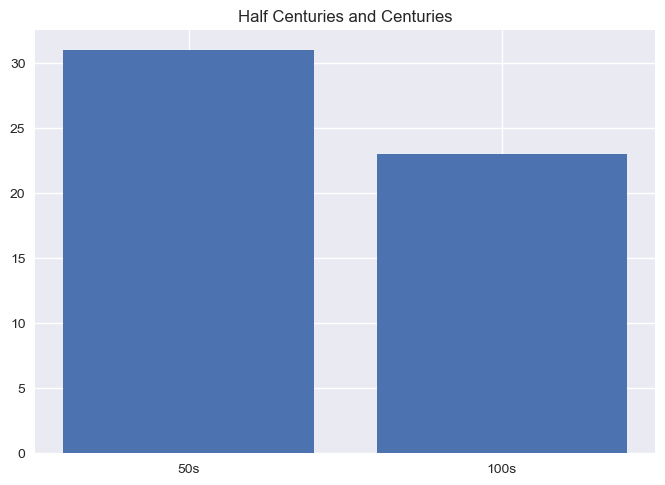

In [61]:
fifties = df[(df['Runs'] >= 50) & (df['Runs'] < 100)].shape[0]
hundreds = df[df['Runs'] >= 100].shape[0]

print("50s:", fifties)
print("100s:", hundreds)

plt.bar(['50s','100s'], [fifties, hundreds])
plt.title("Half Centuries and Centuries")
plt.show()

### Year-wise Performance

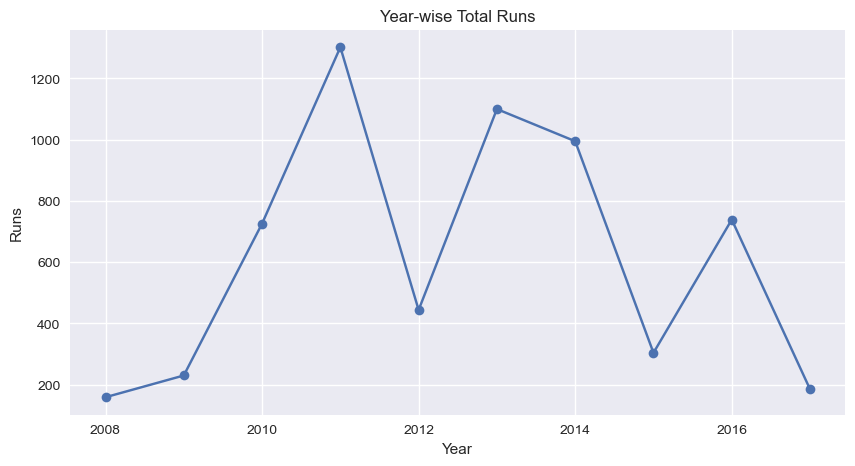

In [62]:
yearly_runs = df.groupby('Year')['Runs'].sum()

plt.figure(figsize=(10,5))
yearly_runs.plot(marker='o')
plt.title("Year-wise Total Runs")
plt.ylabel("Runs")
plt.show()

### Performance Against Each Team

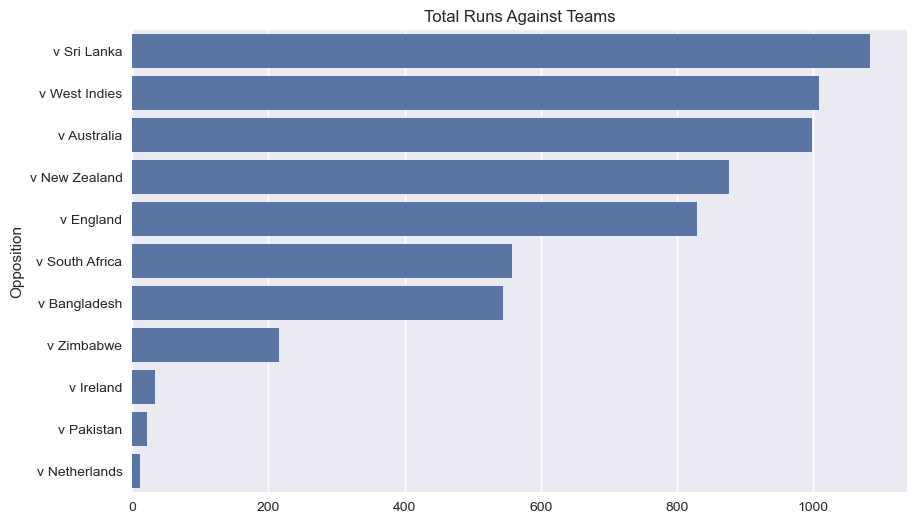

In [63]:
opponent_runs = df.groupby('Opposition')['Runs'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=opponent_runs.values, y=opponent_runs.index)
plt.title("Total Runs Against Teams")
plt.show()

### Performance by Ground

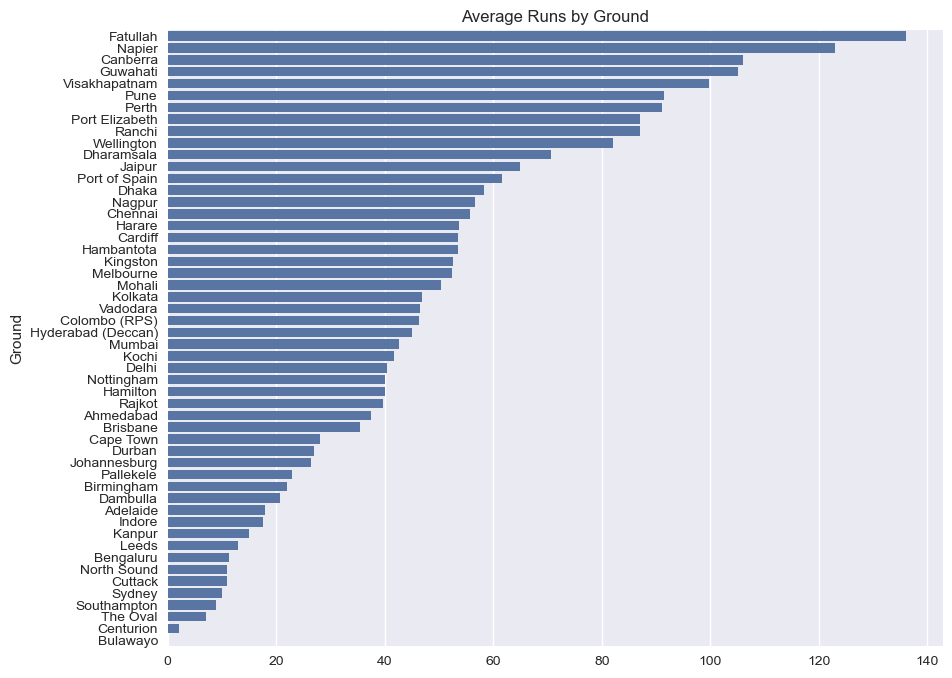

In [64]:
ground_avg = df.groupby('Ground')['Runs'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(x=ground_avg.values, y=ground_avg.index)
plt.title("Average Runs by Ground")
plt.show()

### Batting Position Analysis

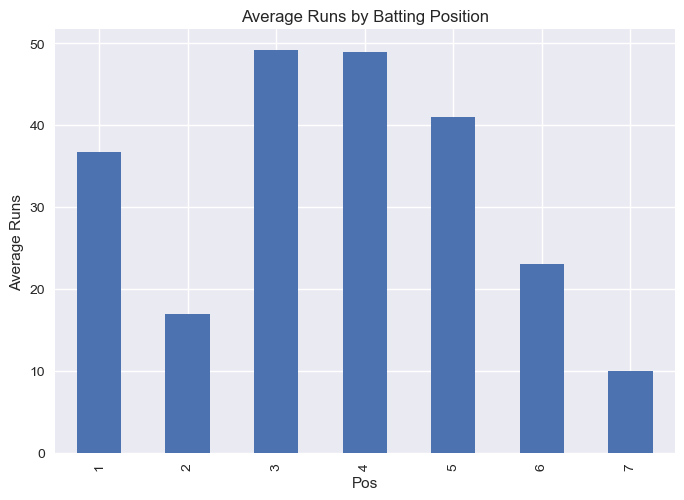

In [65]:
pos_avg = df.groupby('Pos')['Runs'].mean()

pos_avg.plot(kind='bar')
plt.title("Average Runs by Batting Position")
plt.ylabel("Average Runs")
plt.show()

### Dismissal Analysis

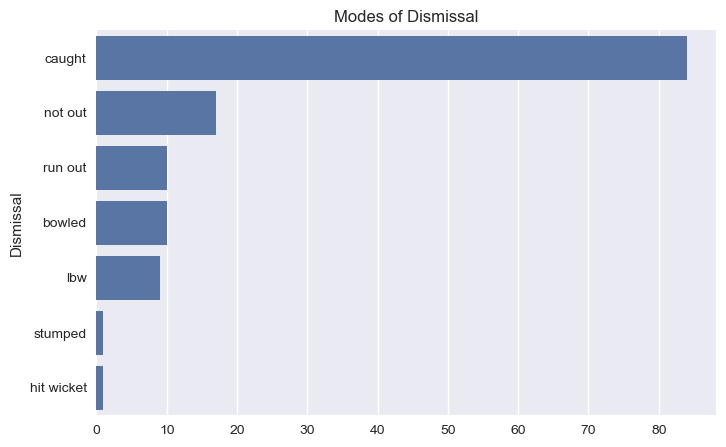

In [66]:
dismissal_count = df['Dismissal'].value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=dismissal_count.values, y=dismissal_count.index)
plt.title("Modes of Dismissal")
plt.show()

### Boundary Contribution %

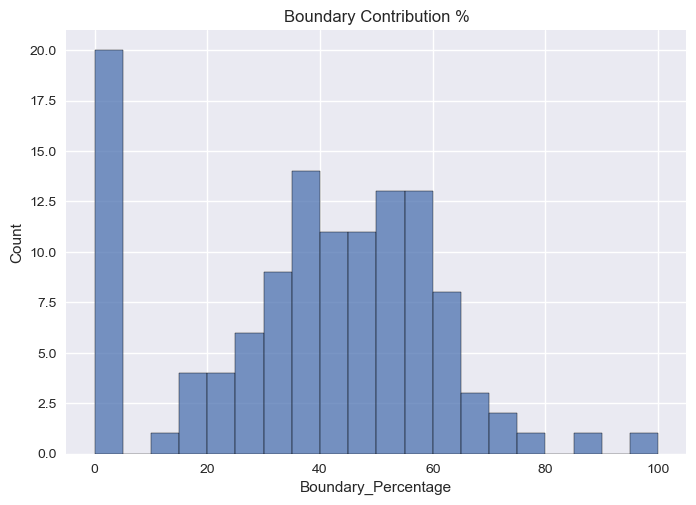

In [67]:
df['Boundary_Runs'] = df['4s']*4 + df['6s']*6
df['Boundary_Percentage'] = (df['Boundary_Runs'] / df['Runs']) * 100

sns.histplot(df['Boundary_Percentage'], bins=20)
plt.title("Boundary Contribution %")
plt.show()

### Correlation Heatmap

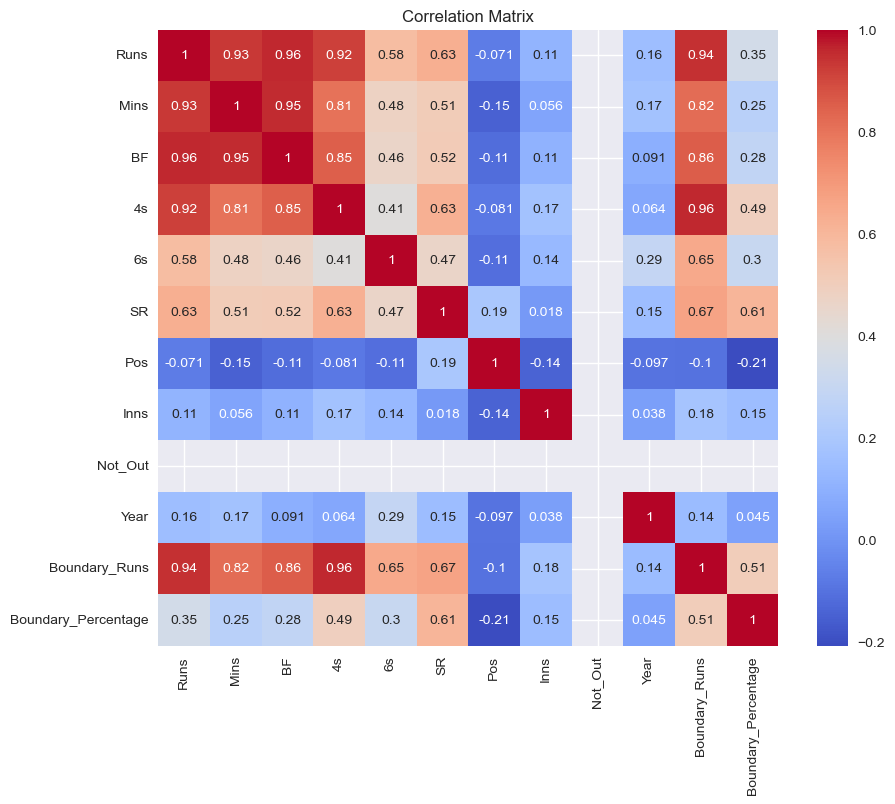

In [68]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Performance When Not Out vs Out

In [69]:
df.groupby('Not_Out')['Runs'].mean()

Not_Out
False    46.848485
Name: Runs, dtype: float64